# Ensemble

We combine all the topic models to create an ensemble representation of the narrative structure.

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns; sns.set_theme(style='white')
from great_tables import GT, style, loc, exibble

local_lib = "../../local_lib"
import sys; sys.path.append(local_lib)
from narrative_parser import NarrativeParser
from narrative_model import NarrativeModel

# Parse Docs

In [2]:
# Parameters
n_chunks = 60 # Number of even chunks to divide the text
n_sw = 20 # Number of stopwords, i.e. most frequent words to cull
n_top_sigs = 500 # Number of significant words to keep, by document entropy (>=500)
# n_top_sigs = 1000 # Number of significant words to keep, by document entropy (>=500)
term_weighting = 'TFIDF' # Term weighting, either TFIDF or TFICF
n_topics = 6 # Number of NMF topics 

In [3]:
# ls ../

In [4]:
sources = "ajtzibab christenson colop christenson_ximenez ximenez".split()
text = {src:{'parser':None, 'model':None} for src in sources}
for src_id in sources:

    # Speak
    print(src_id)

    # Get DOC file
    src_path = f"../{src_id}"
    doc_file = f"{src_path}/{src_id}-DOC.csv"
    doc_idx_file = f"{src_path}/{src_id}-DOC_idx.txt"
    doc_idx = open(doc_idx_file, "r").read().split(",")
    DOC = pd.read_csv(f"{src_path}/{src_id}-DOC.csv").set_index(doc_idx)
    
    # Parse DOC
    parser = NarrativeParser(src_id, DOC)
    parser.n_sw = n_sw
    parser.n_top_sigs = n_top_sigs
    parser.n_chunks = n_chunks
    parser.run()

    # Model 
    if term_weighting == 'TFICF':
        W = parser.TFICF
    else:
        W = parser.TFIDF
    model = NarrativeModel(src_id, parser.CHUNK, W)
    model.n_topics = n_topics
    model.compute_nmf()

    # Append
    text[src_id]['parser'] = parser
    text[src_id]['model'] = model

ajtzibab
christenson
colop
christenson_ximenez
ximenez


# Get Models

In [5]:
# This is to align the topic model numbers
# The column lists were discovered by comparing topic glosses (see below)
def fix_cols(df):
    if src_id == 'ximenez':
        df = df[[0,1,3,2,4,5]]
    elif src_id == 'christenson_ximenez':
        df = df[[0,1,3,2,4,5]]
    df.columns = [0,1,2,3,4,5]
    return df

# Combine all the topic models
theta_list = []
topic_list = []
for src_id in sources:

    # THETA
    theta = text[src_id]['model'].THETA
    theta.columns = [0,1,2,3,4,5] # Convert col names to ints
    # theta = fix_cols(theta)
    theta_list.append(theta)

    # TOPC
    topic = text[src_id]['model'].TOPIC
    # topic = fix_cols(topic.T).T
    topic_list.append(topic)

THETA = pd.concat(theta_list, keys = sources).groupby('chunk_num', observed=False).mean()
TOPIC = pd.concat(topic_list, keys = sources)

# Compare Topics

In [6]:
# Compare topic glosses to see if topics align
TOPIC_gloss = TOPIC.gloss.unstack()
TOPIC_gloss.index.name = 'src_id'
TOPIC_gloss.columns.name = 'topic_id'
TOPIC_gloss.columns = [f"T{col}" for col in TOPIC_gloss.columns]
GT(TOPIC_gloss.reset_index())


src_id,T0,T1,T2,T3,T4,T5
ajtzibab,xib'alb'a,b'alam,ajaw,kaj,k'ajolab',kati't
christenson,xib'alb'a,b'alam,ajaw,kaj,k'ajolab',kati't
colop,xib'alb'a,tojil,ajaw,kaj,k'ajolab',kati't
christenson_ximenez,xibalba,tohil,ahau,cah,caquix,catit
ximenez,xibalba,amac,ahau,cah,caquix,capoh


# Visualize Topics over Time

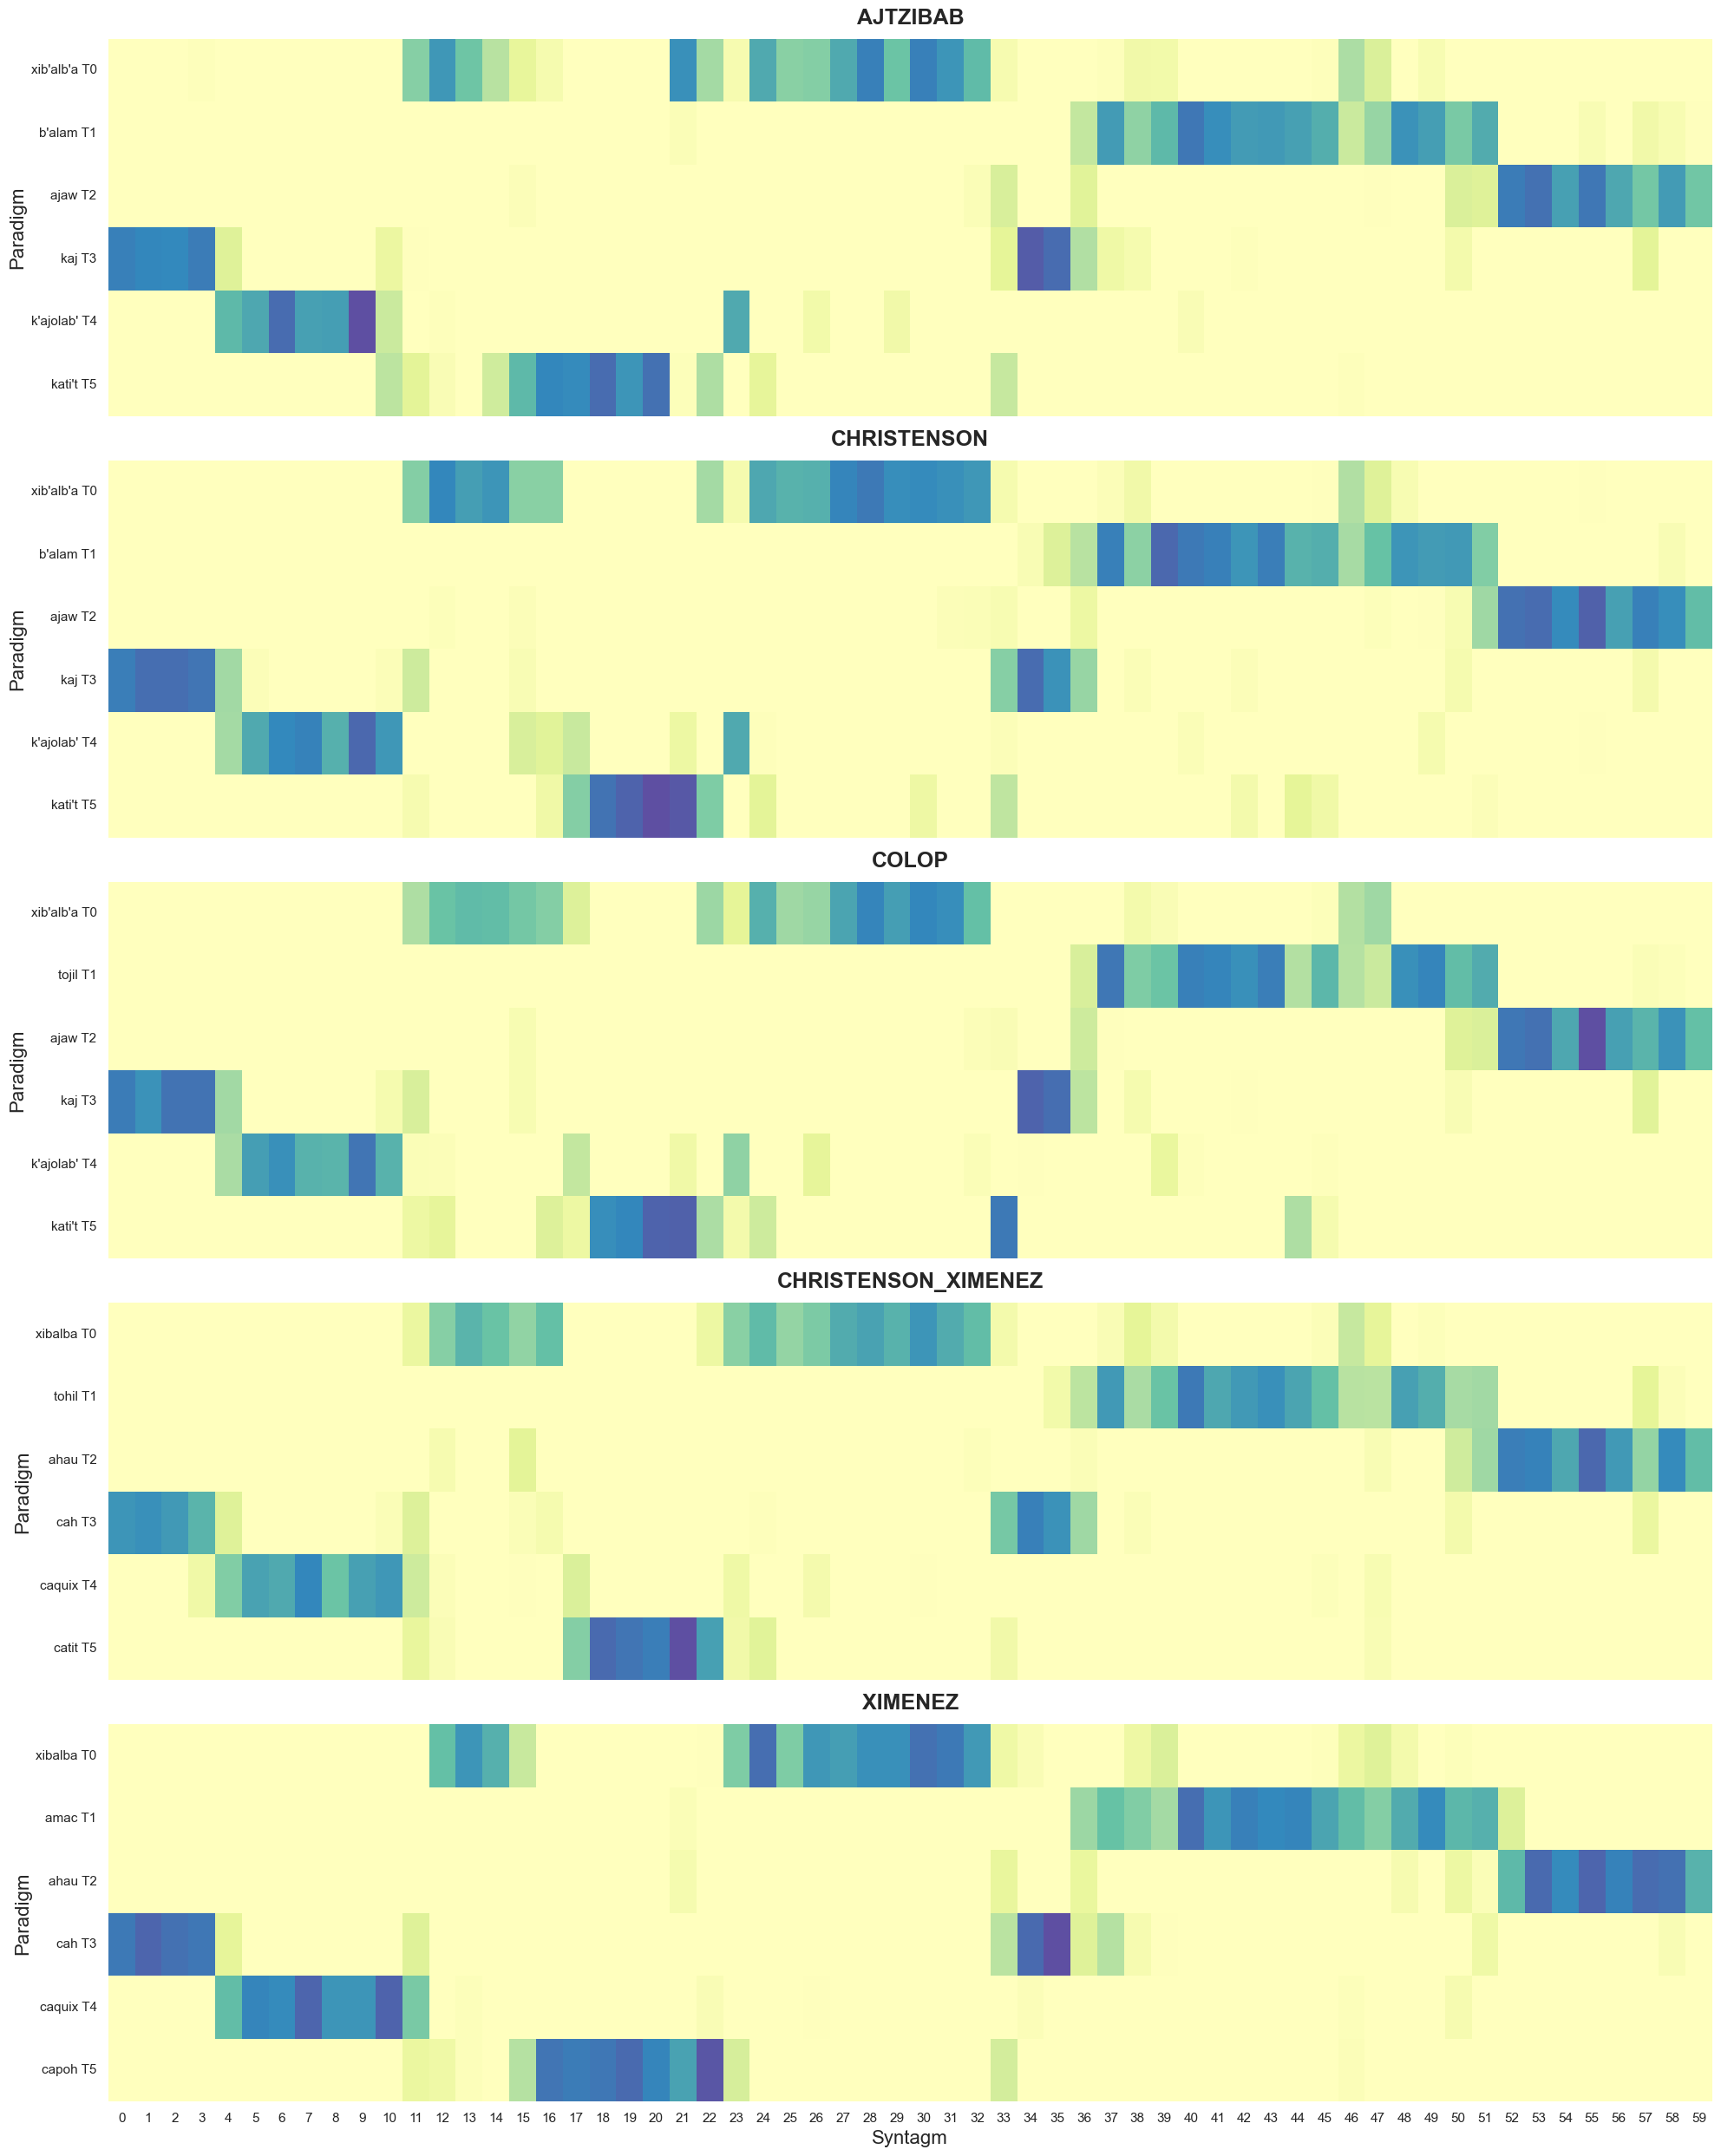

In [7]:
def plot_topics_over_time(src_ids=[]):
    # print(src_ids)
    # viz_order = [0,4,2,5,1,3]
    n_src_ids = len(src_ids)
    fig, ax = plt.subplots(len(src_ids), 1, figsize=(20,5*n_src_ids), sharex=True)
    for i, src_id in enumerate(src_ids):
        y_labels = TOPIC.loc[src_id].label
        X = text[src_id]['model'].THETA.T.set_index(y_labels)
        sns.heatmap(
            X, 
            cmap='Spectral', 
            center=0,
            cbar=None,
            ax=ax[i]
        )
        ax[i].set_title(f"{src_id.upper()}", fontsize=18, fontweight='bold', y=1.02)
        ax[i].set_xlabel("")
        ax[i].set_ylabel("Paradigm", fontsize=16)
    plt.xlabel("Syntagm", fontsize=16)
    plt.tight_layout()
plot_topics_over_time(sources)

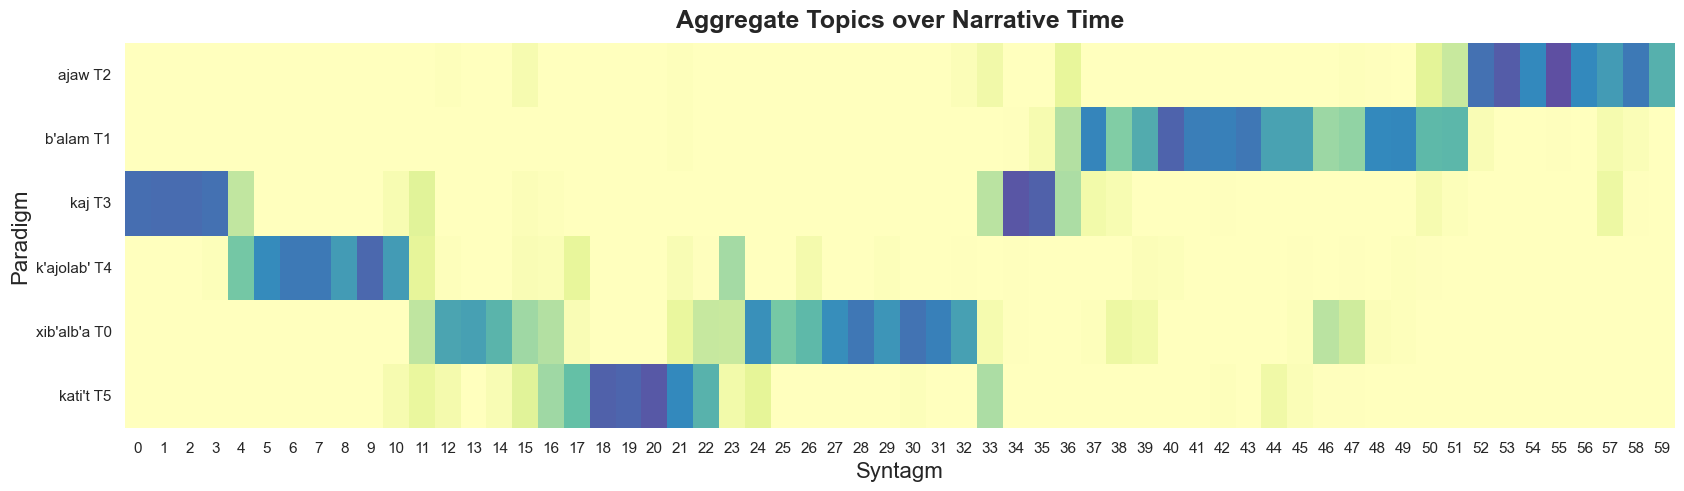

In [8]:
# Set the display order of the topics
viz_order = [2,1,3,4,0,5]

# Replace topic numbers with glosses in the display
y_labels = TOPIC.loc['ajtzibab'].loc[viz_order].label

# Create figure
fig, ax = plt.subplots(figsize=(20,5))
sns.heatmap(
    THETA.T.loc[viz_order].set_index(y_labels), 
    cmap='Spectral', 
    center=0,
    cbar=None
)

# Adjust figure
plt.title(f"Aggregate Topics over Narrative Time", fontsize=18, fontweight='bold', y=1.02)
ax.set_xlabel("Chunk Number", fontsize=10)
ax.set_ylabel("Topic", fontsize=10)
plt.xlabel("Syntagm", fontsize=16)
plt.ylabel("Paradigm", fontsize=16)
plt.savefig(f"ensemble-topic-over-doc.svg", bbox_inches='tight')
plt.savefig(f"ensemble-topic-over-doc.png", bbox_inches='tight')
plt.show()

In [9]:
GT(TOPIC.top_terms.unstack()[viz_order].T.reset_index().rename(columns={'index':'topic_id'}))\
    .tab_style(
        style=style.text(font='Lato'),
        locations=loc.body(columns="topic_id", rows=[0,1,2,3,4,5])
    )

topic_id,ajtzibab,christenson,colop,christenson_ximenez,ximenez
2,"ajaw, ajawab', ajpop, aj, k'iche'","ajaw, ja, pop, ajawab', nim","ajaw, ajawab', ajpop, ja, k'iche'","ahau, ahauab, ahpop, tinamit, quiche","ahau, ahpop, ahauab, quiche, tinamit"
1,"b'alam, tojil, amaq', k'itze', majukutaj","b'alam, amaq', tojil, kitze, majukutaj","tojil, amaq', kitze', majukutaj, aq'ab'","tohil, amac, quitze, mahucutah, acab","amac, tohil, quitze, mahucutah, acab"
3,"kaj, ulew, winaq, tz'aqol, b'itol","kaj, b'it, winaq, tz'aq, ulew","kaj, winaq, ulew, tz'aqol, b'itol","cah, ah, vinac, bit, tzac","cah, bit, vinac, ah, alom"
4,"k'ajolab', kaqix, sipakna, wuqub', xcha'","k'ajolab', sipakna, kaqix, nu, xcha'","k'ajolab', sipakna, kak'ix, xcha', wuqub'","caquix, zipacna, qaholab, in, vvcub","caquix, zipacna, qaholab, vvcub, curi"
0,"xib'alb'a, kame, ajpu, ajawab', wuqub'","xib'alb'a, kame, junajpu, kik', ajawab'","xib'alb'a, kame, xcha', junajpu, ajawab'","xibalba, came, xqha, ahauab, vvcub","xibalba, came, que, ahauab, xqha"
5,"kati't, q'apoj, b'atz', chowen, ati't","kati't, qati't, chowen, ati't, b'atz'","kati't, chowen, b'atz', qati't, ix","catit, batz, ixcatit, atit, chouen","capoh, catit, batz, atit, che"


# Experiments

In [10]:
def get_dfs(src_id):
    o = text[src_id]['parser']
    sigs = o.TFIDF.columns.tolist()
    return pd.concat([o.TFICF, o.TFIDF], keys = ['CF','DF'])\
        .T.swaplevel(axis=1)

def compare_dfs(df, chunk_id):

    global n_common
    
    X = df[chunk_id]
    x = 'CF'
    y = 'DF'

    corr = X.corr().iloc[0,1].round(2)

    thresh = .97
    x_cut = X[x].quantile(thresh).round(2)
    y_cut = X[y].quantile(thresh).round(2)
    x_mask = X[x] >= x_cut
    y_mask = X[y] >= y_cut
    mask_union = x_mask | y_mask        
    mask_intersection = x_mask & y_mask 
    n_common = mask_intersection.sum()
    
    ax = X.plot.scatter(x, y, c='lightblue', figsize=(10,10))
    for i, row in X[mask_union].iterrows():
        color = 'gray'
        if (row[x] >= x_cut) & (row[y] >= y_cut):
            color = 'green'
        ax.annotate(i, xy=(row[x]+.01,row[y]), c=color)
        
    ax.axvline(x_cut, ls='--', lw=1, c='lightgray')
    ax.annotate(x_cut, xy=(x_cut+.01, 0), c='gray')
    ax.axhline(y_cut, ls='--', lw=1, c='lightgray')
    ax.annotate(y_cut, xy=(0, y_cut+.01), c='gray')
    ax.annotate(f"n common: {n_common}", xy=(X[x].max()-.05, X[y].max()+.01))

    sns.despine()
    plt.title(f"Chunk ID: {chunk_id}; thresh={thresh}; corr={corr}", y=1.01, fontfamily="sans serif")

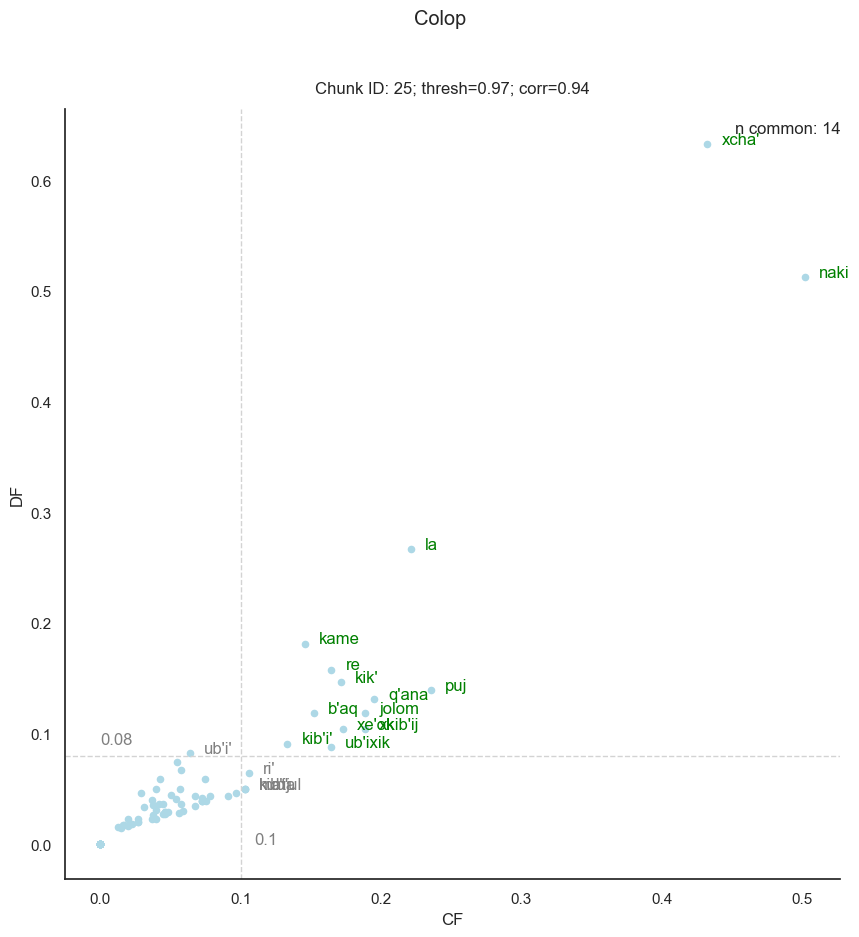

In [11]:
src_id = 'colop'
T = get_dfs(src_id)
chunk_id = np.random.randint(50)
compare_dfs(T, chunk_id)
plt.suptitle(src_id.replace("_", " ").title())
plt.show()

In [12]:
G = T.stack(future_stack=True).groupby('term_str').mean()
G[chunk_id].sort_values(ascending=False).head(n_common)

term_str
xcha'      0.532708
naki       0.507262
la         0.244272
puj        0.187469
kame       0.163726
q'ana      0.163166
re         0.161263
kik'       0.159127
jolom      0.153655
xkib'ij    0.146562
xe'ok      0.138530
b'aq       0.135224
ub'ixik    0.125952
kib'i'     0.112152
Name: 25, dtype: float64